# 상관관계 분석


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('/content/drive/MyDrive/CV_work/AICE공부/data_csv/1_used_car_prices.csv', usecols=['age_years', 'accident_count','horsepower','mileage_km'])

In [34]:
# df.info()
# df.head(5)
df.describe()

,age_years,mileage_km,horsepower,accident_count
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,7.054000,105972.54300,252.316000,0.719000
std,4.438557,69265.32343,89.029638,1.134604
min,0.000000,1058.00000,82.000000,0.000000
25%,3.000000,47589.00000,180.000000,0.000000
50%,7.000000,102769.00000,249.000000,0.000000
75%,11.000000,152647.50000,332.000000,1.000000
max,14.000000,284163.00000,415.000000,4.000000


In [26]:
corr_matrix = df.corr()
corr_matrix
# 결과는 표로 나오는데
# 0.7~1.0 -> 강한 비례
# -0.7 ~ -1.0 -> 강한 반비례
# -0.3 ~ 0.3 -> 무관

,age_years,mileage_km,horsepower,accident_count
age_years,1.000000,0.860690,-0.004879,0.019713
mileage_km,0.860690,1.000000,0.033306,0.003346
horsepower,-0.004879,0.033306,1.000000,0.002069
accident_count,0.019713,0.003346,0.002069,1.000000


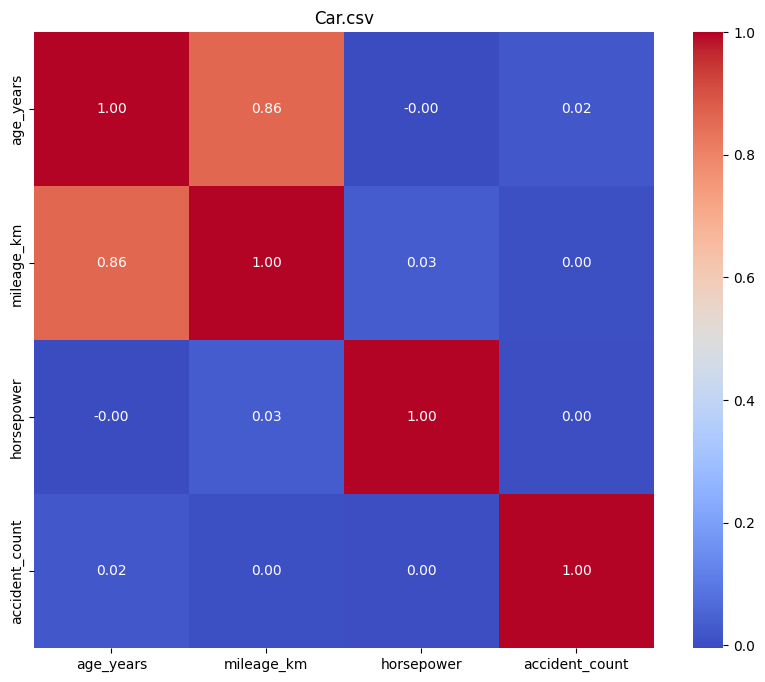

In [28]:
# corr결과 시각화하기

# 표 전체 크기 정의
plt.figure(figsize = (10,8))

# sns로 표현
sns.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')

# data는 말할게 없죠?
# annot : 숫자 주석 자동 표시
# cmap은 다른거 쓸일 없나? 빨강이 1쪽 파랑이 -1쪽
# fmt는 소숫점 표시

# 그래프 타이틀
plt.title('Car.csv')

# 그래프 표시
plt.show()

In [ ]:
# 위에서는 df를 pd.read할 때 원하는 정보만 가져왔지만
# 실제로는 아래처럼 필요한 정보만 써야함

main_ingredients = ['horsepower','price_krw']

corr_matrix_main = df[main_ingredients].corr() # 넣으면 [[]]형태로 2차원 형태임. 컬럼을 여러개 선택할때는 2차원으로 먹어야댐.

In [29]:
# 결과값 리스트로 받기.

score_corr = corr_matrix['mileage_km'] # mileage_km행을 선택한거잖아요. 즉, mileage_km과 관련된 애들만 가져온다 -> 리스트로

score_corr = score_corr.drop('mileage_km') # 자기자신과는 항상 1이므로 지우기

best_ingredient = score_corr.abs().idxmax() # 가장 관계가 큰 대상 찾기.
# abs는 절댓값
# idxmax는 값이 가장 큰 인덱스를 내보내는데
# 인덱스가 컬럼이고, 값이 상관계수니까 이렇게 함.

best_ingredient

'age_years'

In [30]:
# 절대값 없애고, max를 min으로 바꾸면 가장 방해하는 애겠죠
worst_ingredient = score_corr.idxmin()
worst_ingredient

'accident_count'

In [33]:
# 순서 매기기 -> 내림차순 정렬

ranked_corr  = score_corr.abs().sort_values(ascending = False)
# 절댓값은 그렇다 치고
# sort_values -> 정렬인데 디폴트는 오름차순임
# ascending = False가 내림차순으로 변경.

print(ranked_corr)

age_years         0.860690
horsepower        0.033306
accident_count    0.003346
Name: mileage_km, dtype: float64


In [39]:
# 필터링

# 조건에 맞는 친구들만 다시 계산하는거죠.

subset_df = df[df['mileage_km'] > 102769.0].corr()


print(subset_df[['mileage_km','age_years']]) # 이건 그냥 인덱싱이고, 여러개면 2차원임을 기억.


                mileage_km  age_years
age_years         0.476599   1.000000
mileage_km        1.000000   0.476599
horsepower        0.090474  -0.010135
accident_count    0.003087   0.044802
